In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.dates import DateFormatter


In [3]:
def select_by_latlon(ds, lat_target, lon_target):
    lat = ds['nav_lat'].values
    lon = ds['nav_lon'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print(x_idx, y_idx)
    return ds['tos_con'].isel(y=y_idx, x=x_idx)



In [4]:
from OceanDataStore import OceanDataCatalog

In [5]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [6]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [7]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [8]:
catalog.Items[4]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d>

In [9]:
ds1 = catalog.open_dataset(id=catalog.Items[4].id, start_datetime='1990-01', end_datetime='1990-12')
ds1

<xarray.Dataset> Size: 24GB
Dimensions:                (time_counter: 73, y: 1206, x: 1440, axis_nbounds: 2)
Coordinates:
    nav_lat                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    nav_lon                (y, x) float64 14MB dask.array<chunksize=(1206, 1440), meta=np.ndarray>
    time_centered          (time_counter) datetime64[ns] 584B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 584B 1990-01-03T12:0...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/50)
    empmr                  (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfempds                (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    hfevapds               (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    ...                     ...
    time_centered_bounds   (time_counter, axis_nbounds) datetime64[ns] 1kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds    (time_counter, axis_nbounds) datetime64[ns] 1kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    tnpeo                  (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    tossq_con              (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 507MB dask.array<chunksize=(1, 1206, 1440), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA025_ERA5_5d_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-18 20:34:01 GMT
    uuid:         78bf1118-219d-4f11-9974-e1ae49742378

C:\Users\TomAH\AppData\Local\Temp\ipykernel_34328\3205395635.py:8: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(ds1['nav_lon'], ds1['nav_lat'], nan_mask, cmap='gray_r', shading='auto')


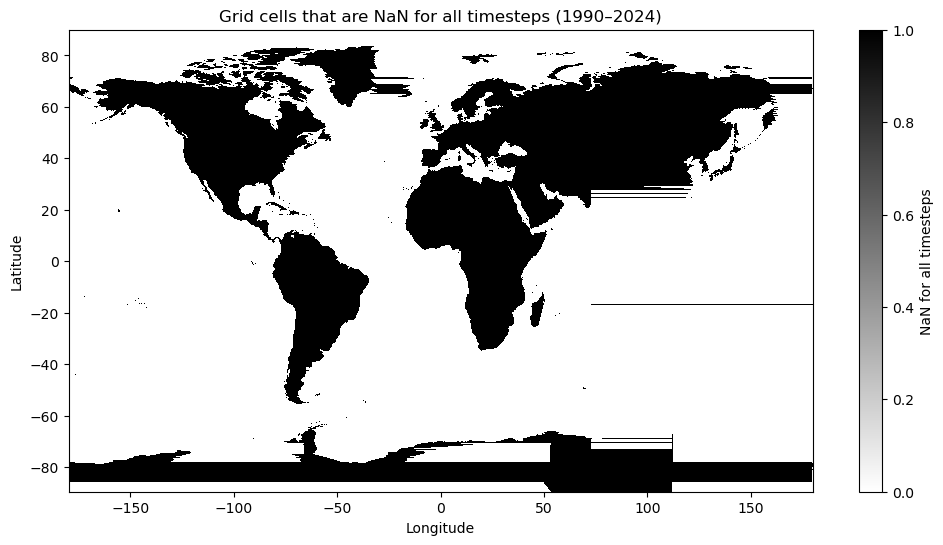

In [10]:
import matplotlib.pyplot as plt
import numpy as np


nan_mask = ds1['tos_con'].isnull().all(dim='time_counter')

plt.figure(figsize=(12, 6))
plt.pcolormesh(ds1['nav_lon'], ds1['nav_lat'], nan_mask, cmap='gray_r', shading='auto')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Grid cells that are NaN for all timesteps in 1990')
plt.colorbar(label='NaN for all timesteps')
plt.show()
